### ARIMA Modeling: Austrian Electricity Prices
by Paul Ringler

This is a short recap of EDA results so far.
#### Time Series Characteristics

**Outcome to be modelled:** Monthly electricity prices (2015-01 to 2025-09, N=128)
- **Variable:** `price_combined` (EXAA Day-Ahead + MC Auction average)
- **Overall Mean:** 78.09 EUR/MWh, Std: 76.83 EUR/MWh
- **Range:** 18.0 - 488.0 EUR/MWh

**Structural Breaks:**
- COVID-19 price dip detected at 2020-01 (Ziv-Andrews test)
- Main crisis escalation at 2021-09 (Ukraine war)

**Assumed Regime Structure** (identified via EDA, addressed in Feature Engineering):
- Stable Pre-Shock (2015-01 to 2020-12, n=72): Stationary (ADF p=0.034)
- Price Shock (2021-01 to 2023-02, n=26): Non-stationary, extreme volatility
- Stable Post-Shock (2023-03 to 2025-08, n=30): Stationary (ADF p=0.027)

- Full series: Non-stationary (ADF p=0.14, KPSS p=0.012)
 

**Stationarity and Impact of Structural Break:**
- Complete series: Slow ACF decay (non-stationary) due to level shifts between periods
- Individual stable periods: Fast exponential decay, PACF cutoff at lag 1-2 (AR structure)
- PACF suggests AR(1) or AR(2) within stable periods
- Modeling strategy: Test on complete series first, then evaluate need for period-specific models

**Seasonality:**
- Moderate seasonal strength (0.36)
- Multiplicative seasonal pattern (±20% around trend)
- Peak: December (96.85), Trough: May (57.00)

---

#### Modeling Assumptions

1. **Differencing:** d=1 required (confirmed by ADF/KPSS)
2. **AR/MA Structure:** Grid search for p,q ∈ {0,1,2}. PACF suggests AR(1) or AR(2) as starting point.
1. **Stationarity Approach:** Test ARIMA on complete series first (structural breaks will challenge this). ARIMAX and period-specific modeling if necessary.
4. **Train-Test Split:** Temporal split (no random shuffle)
   - Train: 2015-01 to 2023-12 (N=108)
   - Test: 2024-01 to 2025-06 (N=18)
   **Note:** Training on the pre-shock and shock-periods reflects a real-world scenario where structural breaks cannot be excluded ex-ante and a "new-normal" needs forecasting.
5. **Model Selection Criteria:** AIC/BIC (in-sample) + RMSE/MAE (out-of-sample)

---

#### Modeling Strategy

**Phase 1: Baseline Models (Complete Series)**
- Persistence (ŷ_t = y_{t-1})
- Seasonal Naive (ŷ_t = y_{t-12})

**Phase 2: Univariate ARIMA**
- ARIMA(p,d,q) via grid search (p,q ∈ {0,1,2}, d ∈ {0,1})
- **Expected:** Poor performance due to structural breaks
- **Purpose:** Baseline model to test if exogenous variables provide sufficient information for improved prognosis
- Residual diagnostics (ACF, Ljung-Box, normality)

**Phase 3: ARIMAX with Single Exogenous Variables (Complete Series)**
Individual models to test incremental improvement and avoid multicollinearity:
- ARIMAX + Gas prices (`oegpi_month`) - strongest predictor (r=0.84)
- ARIMAX + CO2 prices (`carbonprices_primary_market`) - moderate (r=0.70)
- ARIMAX + Climate (`climate_hdd_at`, `climate_cdd_at`) - test despite weak correlation
- ARIMAX + Imports (`econ_imports_total_EUR`) - demand proxy (r=0.70)

**Excluded variables due to multicollinearity or irrelevance:**
- `econ_imports_energy_EUR`: Nearly redundant with gas prices (r=0.91)
- `econ_exports_total_EUR`: Nearly redundant with imports (r=0.96)
- `econ_count_overnight_stays`: No correlation with price (r=0.08)
- `prod_renewables_pct_total`: No correlation with price (r=-0.02)
- `econ_consumer_price_index`: High correlation with CO2 (r=0.86), inflation proxy less relevant

**Phase 4: ARIMAX with Combined Exogenous Variables**
Test combinations to maximize explanatory power while avoiding multicollinearity:
- ARIMAX + Gas + CO2
- ARIMAX + Gas + CO2 + Climate
- ARIMAX + Gas + CO2 + Imports (check coefficient stability due to CO2-Imports correlation r=0.88)

**Selection criteria:**
- AIC/BIC improvement vs. single-variable models
- Coefficient sign stability (expected: Gas+, CO2+, HDD+, CDD+, Imports+)
- Standard errors remain reasonable

**Phase 5: Validation**
- Time Series Cross-Validation (rolling/expanding window)
- Final model selection and forecast


---

#### Exogenous Variables - Expected Effects 

**Multicollinearity Assessment (Correlation Analysis):**
Critical correlations identified:
- Gas ↔ Energy Imports: r=0.91 → Energy Imports excluded
- Exports ↔ Imports Total: r=0.96 → Exports excluded  
- CO2 ↔ Imports: r=0.88 → Monitor in combined models
- HDD ↔ Renewables: r=-0.85 → Causal link, both retained

Weak/No correlation with price:
- Climate variables (HDD: r=-0.01, CDD: r=0.02) → Test for non-linear effects
- Renewables share (r=-0.02) → Excluded
- Overnight stays (r=0.08) → Excluded

**Primary Driver:**
- **Gas Prices** (`oegpi_month`): **Strong** effect expected
  - Gas is a marginal fuel in Austria and sets electricity price
  - Pre-shock correlation: moderate, Post-shock: high
  
  **Secondary Drivers:**
- **CO2 Prices** (`carbonprices_primary_market`):**Moderate** effect expected
  - EU ETS increases fossil generation costs
  - Effect stronger when fossil share is high. Since share of renewable energy in Austria ranges seasonally from ~70% to ~90% this effect is expected to be rather small.

- **Climate** (`climate_hdd_at`, `climate_cdd_at`): **Moderate** effect
  - Heating Degree Days → winter demand ↑
  - Cooling Degree Days → summer demand ↑
  
- **Production Mix** (`prod_renewable_*`, `prod_fossil_*`): **Complex** effect expected
  - High renewable generation → lower prices (merit order)
  - Fossil production usually correlates with high demand periods, may be offset by Austria´s substantial 
pumped storage power plants capacities.

- **Economic Indicators** (`econ_prod_index_industry`): **Complex** effects expected
No monthly measure of GDP growth was available and critical data such as industrial production is only available for a few months. Expectations for data available for the period of analysis:
  - Exports total, Overnight stays, Consumer Price Index: Proxy variables for economic climate. Will be tested for effect. Weak effect expected
  - Imports and Energy Imports: Strong effect expected, also multicollinearity between the two.


**Hypothesis:** Gas prices will explain most variance (r=0.84). CO2 prices provide 
secondary contribution (r=0.70). Climate variables and Imports may add marginal 
improvement despite weak bivariate correlations (potential interaction effects).

**Note on Train Data:**
Train period be from 2020-01 onwards only, since no data for `oegpi_monthly` is available earlier.

**Note on Test Data:**
Test period limited to 2024-01 to 2025-06 (18 months) due to exogenous 
variable availability. Climate variables for 2025 (HDD/CDD) filled with 
2024 values under the assumption of stable year-over-year climate patterns.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

In [54]:
#Initial feature engineering for climate data

print("CLIMATE DATA AVAILABILITY:")
print(f"  HDD Austria: {df['climate_hdd_at'].notna().sum()} non-null values")
print(f"  Last available: {df[df['climate_hdd_at'].notna()].index.max()}")
print(f"  Test period needs: {test.index.min()} to {test.index.max()}")
print()

# Fill 2025 climate with 2024 values (seasonal, lag-12)
climate_vars = ['climate_hdd_at', 'climate_cdd_at', 'climate_hdd_eu', 'climate_cdd_eu']

for var in climate_vars:
    # Find missing indices in test period
    missing_mask = test[var].isna()
    missing_dates = test[missing_mask].index
    
    if len(missing_dates) > 0:
        print(f"Filling {var}:")
        for date in missing_dates:
            # Get same month from previous year (lag-12)
            lag12_date = date - pd.DateOffset(months=12)
            if lag12_date in df.index:
                lag12_value = df.loc[lag12_date, var]
                test.loc[date, var] = lag12_value
                print(f"  {date.strftime('%Y-%m')} ← {lag12_date.strftime('%Y-%m')} (value: {lag12_value:.1f})")

print("\nCLIMATE DATA AFTER FILL:")
for var in climate_vars:
    print(f"  {var}: {test[var].notna().sum()}/{len(test)} non-null")

CLIMATE DATA AVAILABILITY:
  HDD Austria: 120 non-null values
  Last available: 2024-12-01 00:00:00
  Test period needs: 2024-01-01 00:00:00 to 2025-06-01 00:00:00

Filling climate_hdd_at:
  2025-01 ← 2024-01 (value: 566.8)
  2025-02 ← 2024-02 (value: 356.7)
  2025-03 ← 2024-03 (value: 335.3)
  2025-04 ← 2024-04 (value: 243.1)
  2025-05 ← 2024-05 (value: 127.4)
  2025-06 ← 2024-06 (value: 50.2)
Filling climate_cdd_at:
  2025-01 ← 2024-01 (value: 0.0)
  2025-02 ← 2024-02 (value: 0.0)
  2025-03 ← 2024-03 (value: 0.0)
  2025-04 ← 2024-04 (value: 0.0)
  2025-05 ← 2024-05 (value: 0.0)
  2025-06 ← 2024-06 (value: 7.0)
Filling climate_hdd_eu:
  2025-01 ← 2024-01 (value: 522.7)
  2025-02 ← 2024-02 (value: 368.1)
  2025-03 ← 2024-03 (value: 336.0)
  2025-04 ← 2024-04 (value: 239.2)
  2025-05 ← 2024-05 (value: 100.0)
  2025-06 ← 2024-06 (value: 39.8)
Filling climate_cdd_eu:
  2025-01 ← 2024-01 (value: 0.0)
  2025-02 ← 2024-02 (value: 0.0)
  2025-03 ← 2024-03 (value: 0.0)
  2025-04 ← 2024-04 (val

In [55]:
# Load data
df = pd.read_csv(r'../../data/processed/data_analysis_ready.csv', 
                 encoding='cp1252',  # to account for regional data settings
                 parse_dates=['date_dt']) # data is csv, date_dt needs to be parsed as date on loading

#keep monthly data only
df = df[df['aggregation_level'] == 'monthly'].copy()

#set datetime index
df = df.set_index('date_dt') 
print(f"Index type: {type(df.index)}")
print(f"Index range: {df.index.min()} to {df.index.max()}")

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index range: 2015-01-01 00:00:00 to 2025-08-01 00:00:00


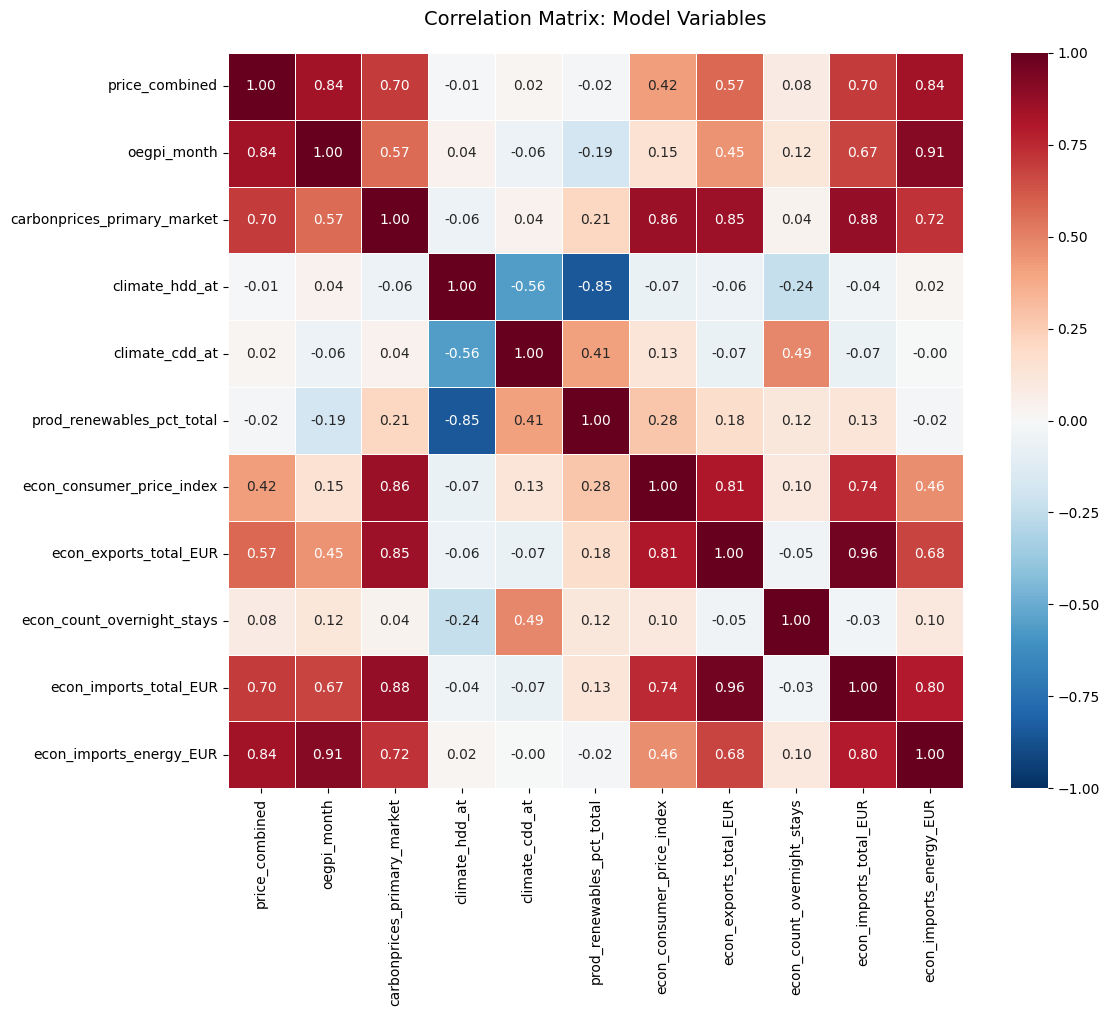


High Correlations (|r| > 0.7):
price_combined                 ↔ oegpi_month                   :  0.84
price_combined                 ↔ econ_imports_total_EUR        :  0.70
price_combined                 ↔ econ_imports_energy_EUR       :  0.84
oegpi_month                    ↔ econ_imports_energy_EUR       :  0.91
carbonprices_primary_market    ↔ econ_consumer_price_index     :  0.86
carbonprices_primary_market    ↔ econ_exports_total_EUR        :  0.85
carbonprices_primary_market    ↔ econ_imports_total_EUR        :  0.88
carbonprices_primary_market    ↔ econ_imports_energy_EUR       :  0.72
climate_hdd_at                 ↔ prod_renewables_pct_total     : -0.85
econ_consumer_price_index      ↔ econ_exports_total_EUR        :  0.81
econ_consumer_price_index      ↔ econ_imports_total_EUR        :  0.74
econ_exports_total_EUR         ↔ econ_imports_total_EUR        :  0.96
econ_imports_total_EUR         ↔ econ_imports_energy_EUR       :  0.80


In [56]:
#correlation matrix of exogenous variables


import seaborn as sns
import matplotlib.pyplot as plt

# Define model variables
model_vars = [
    'price_combined',
    'oegpi_month',
    'carbonprices_primary_market',
    'climate_hdd_at',
    'climate_cdd_at',
    'prod_renewables_pct_total',
    'econ_consumer_price_index',
    'econ_exports_total_EUR',
    'econ_count_overnight_stays',
    'econ_imports_total_EUR',
    'econ_imports_energy_EUR'
]

# Calculate correlation matrix
corr = df[model_vars].corr()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Model Variables', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Print high correlations (|r| > 0.7)
print("\nHigh Correlations (|r| > 0.7):")
print("="*50)
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"{corr.columns[i]:30s} ↔ {corr.columns[j]:30s}: {corr.iloc[i, j]:5.2f}")

##### Train-Test Split

In [57]:
# Temporal train-test split
# Adjusted test period to match data availability
split_date = '2023-12'
train_start = '2020-01'   # Where most exogenous variables end

train = df[(df.index >= train_start) & (df.index <= split_date)].copy()
test = df[(df.index > split_date) & (df.index <= test_end)].copy()

print(f"Train: {train.index.min()} to {train.index.max()} (n={len(train)})")
print(f"Test:  {test.index.min()} to {test.index.max()} (n={len(test)})")

Train: 2020-01-01 00:00:00 to 2023-12-01 00:00:00 (n=48)
Test:  2024-01-01 00:00:00 to 2025-06-01 00:00:00 (n=18)


##### Baseline models

In [58]:
y_train = train['price_combined']
y_test = test['price_combined']

# Baseline 1: Persistence (same as yesterday)
persistence_pred = y_train.iloc[-1]  # Last value of train
persistence_forecast = np.full(len(y_test), persistence_pred)

# Baseline 2: Seasonal Naive (same month last year)
seasonal_naive_forecast = []
for i in range(len(y_test)):
    # Get value from 12 months ago in train
    if len(y_train) >= 12:
        seasonal_naive_forecast.append(y_train.iloc[-(12-i)])
    else:
        seasonal_naive_forecast.append(y_train.mean())

seasonal_naive_forecast = np.array(seasonal_naive_forecast)

# Calculate RMSE
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse_pers = np.sqrt(mean_squared_error(y_test, persistence_forecast))
mae_pers = mean_absolute_error(y_test, persistence_forecast)
mape_pers = mean_absolute_percentage_error(y_test, persistence_forecast) * 100
bias_pers = np.mean(persistence_forecast - y_test)
max_error_pers = np.max(np.abs(persistence_forecast - y_test))

rmse_seas = np.sqrt(mean_squared_error(y_test, seasonal_naive_forecast))
mae_seas = mean_absolute_error(y_test, seasonal_naive_forecast)
mape_seas = mean_absolute_percentage_error(y_test, seasonal_naive_forecast) * 100
bias_seas = np.mean(seasonal_naive_forecast - y_test)
max_error_seas = np.max(np.abs(seasonal_naive_forecast - y_test))

print("BASELINE MODEL PERFORMANCE:")
print(f"Persistence:    RMSE={rmse_pers:.2f}, MAE={mae_pers:.2f}, MAPE={mape_pers:.1f}%, Bias={bias_pers:.2f}, Max Error={max_error_pers:.2f}")
print(f"Seasonal Naive: RMSE={rmse_seas:.2f}, MAE={mae_seas:.2f}, MAPE={mape_seas:.1f}%, Bias={bias_seas:.2f}, Max Error={max_error_seas:.2f}")

BASELINE MODEL PERFORMANCE:
Persistence:    RMSE=30.76, MAE=21.56, MAPE=20.6%, Bias=-14.56, Max Error=68.00
Seasonal Naive: RMSE=56.42, MAE=48.78, MAPE=56.2%, Bias=-10.44, Max Error=111.50


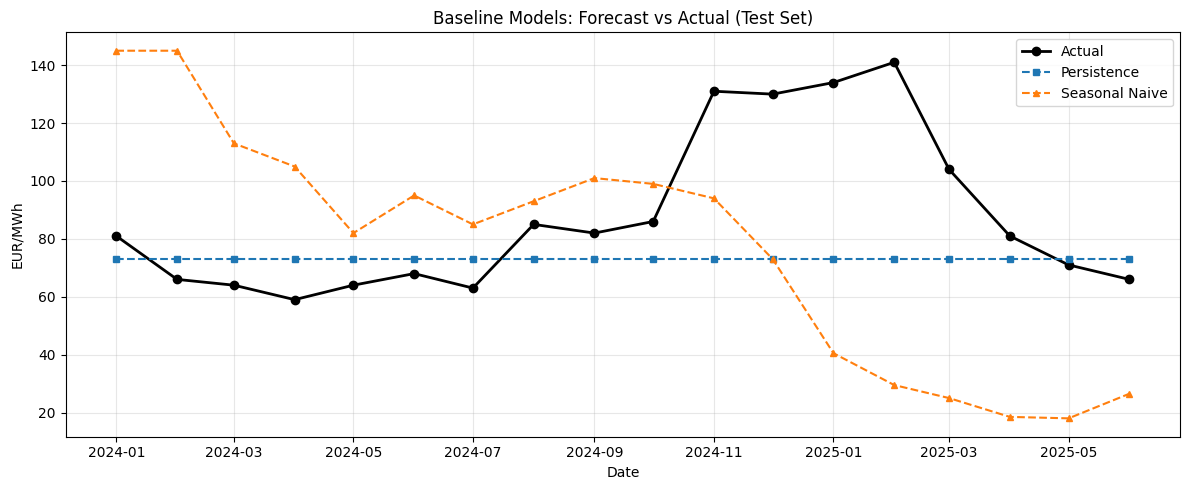

In [59]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 5))

# Plot actual test values
ax.plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=2, markersize=6, color='black')

# Plot forecasts
ax.plot(y_test.index, persistence_forecast, 's--', label='Persistence', linewidth=1.5, markersize=5)
ax.plot(y_test.index, seasonal_naive_forecast, '^--', label='Seasonal Naive', linewidth=1.5, markersize=5)

ax.set_xlabel('Date')
ax.set_ylabel('EUR/MWh')
ax.set_title('Baseline Models: Forecast vs Actual (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Establishing full baseline ARIMA: 

- Full grid search for full period and from 2020-01 (gas availability)

In [77]:
# Phase 2: Univariate ARIMA - Extended Grid Search (d=0 and d=1)

models_to_test = [
    # d=0 (no differencing - level models)
    (1, 0, 0),  # AR(1)
    (2, 0, 0),  # AR(2) 
    (1, 0, 1),  # ARMA(1,1)
    (2, 0, 1),  # ARMA(2,1)
    # d=1 (differenced - original tests)
    (1, 1, 0),  # AR(1) differenced
    (2, 1, 0),  # AR(2) differenced (previous best)
    (1, 1, 1),  # ARMA(1,1) differenced
    (2, 1, 1),  # ARMA(2,1) differenced
]

results = []

for order in models_to_test:
    try:
        model = ARIMA(y_train, order=order)
        fit = model.fit()
        forecast = fit.forecast(steps=len(y_test))
        
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        mae = mean_absolute_error(y_test, forecast)
        mape = mean_absolute_percentage_error(y_test, forecast) * 100
        bias = np.mean(forecast - y_test)
        
        results.append({
            'order': order,
            'aic': fit.aic,
            'bic': fit.bic,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'bias': bias,
            'model': fit,
            'forecast': forecast
        })
        
        print(f"ARIMA{order}: AIC={fit.aic:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
        
    except Exception as e:
        print(f"ARIMA{order}: Failed - {e}")

# Best by RMSE (more interpretable than AIC for comparison)
best_model = min(results, key=lambda x: x['rmse'])
print(f"\nBest model by RMSE: ARIMA{best_model['order']}")
print(f"  AIC={best_model['aic']:.2f}, RMSE={best_model['rmse']:.2f}, MAE={best_model['mae']:.2f}, MAPE={best_model['mape']:.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=2, color

_IncompleteInputError: incomplete input (1282213048.py, line 53)


RESIDUAL DIAGNOSTICS - BEST MODEL

Ljung-Box Test (H0: No autocorrelation):
      lb_stat  lb_pvalue
12  15.466475   0.216912
24  19.257525   0.738120

Shapiro-Wilk Test (H0: Normal distribution):
  Statistic=0.8602, p-value=0.0000


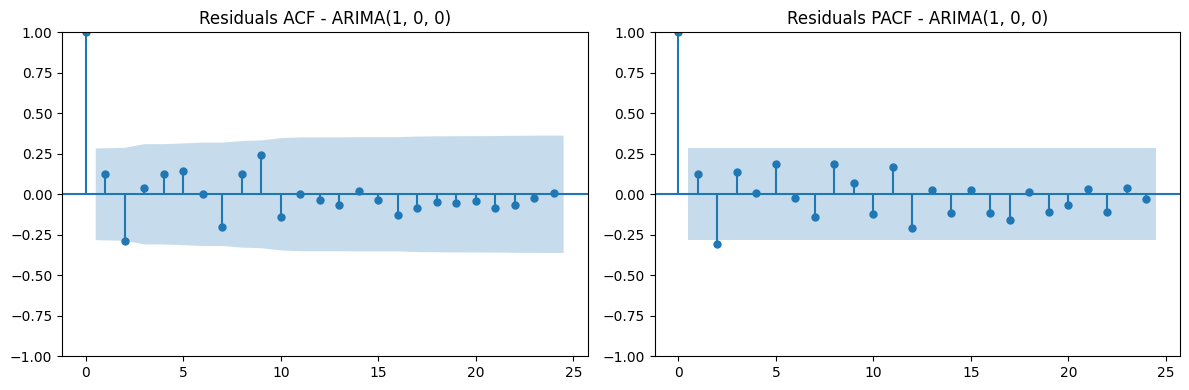

In [69]:
# Phase 2: Univariate ARIMA -
# RESIDUAL DIAGNOSTICS (Best Model)

best_fit = best_model['model']
residuals = best_fit.resid

print("\n" + "="*50)
print("RESIDUAL DIAGNOSTICS - BEST MODEL")
print("="*50)

# Ljung-Box Test (no autocorrelation in residuals)
lb_test = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("\nLjung-Box Test (H0: No autocorrelation):")
print(lb_test)

# Normality Test (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test (H0: Normal distribution):")
print(f"  Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

# ACF/PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=24, ax=axes[0], alpha=0.05)
axes[0].set_title(f'Residuals ACF - ARIMA{best_model["order"]}')

plot_pacf(residuals, lags=24, ax=axes[1], alpha=0.05)
axes[1].set_title(f'Residuals PACF - ARIMA{best_model["order"]}')

plt.tight_layout()
plt.show()

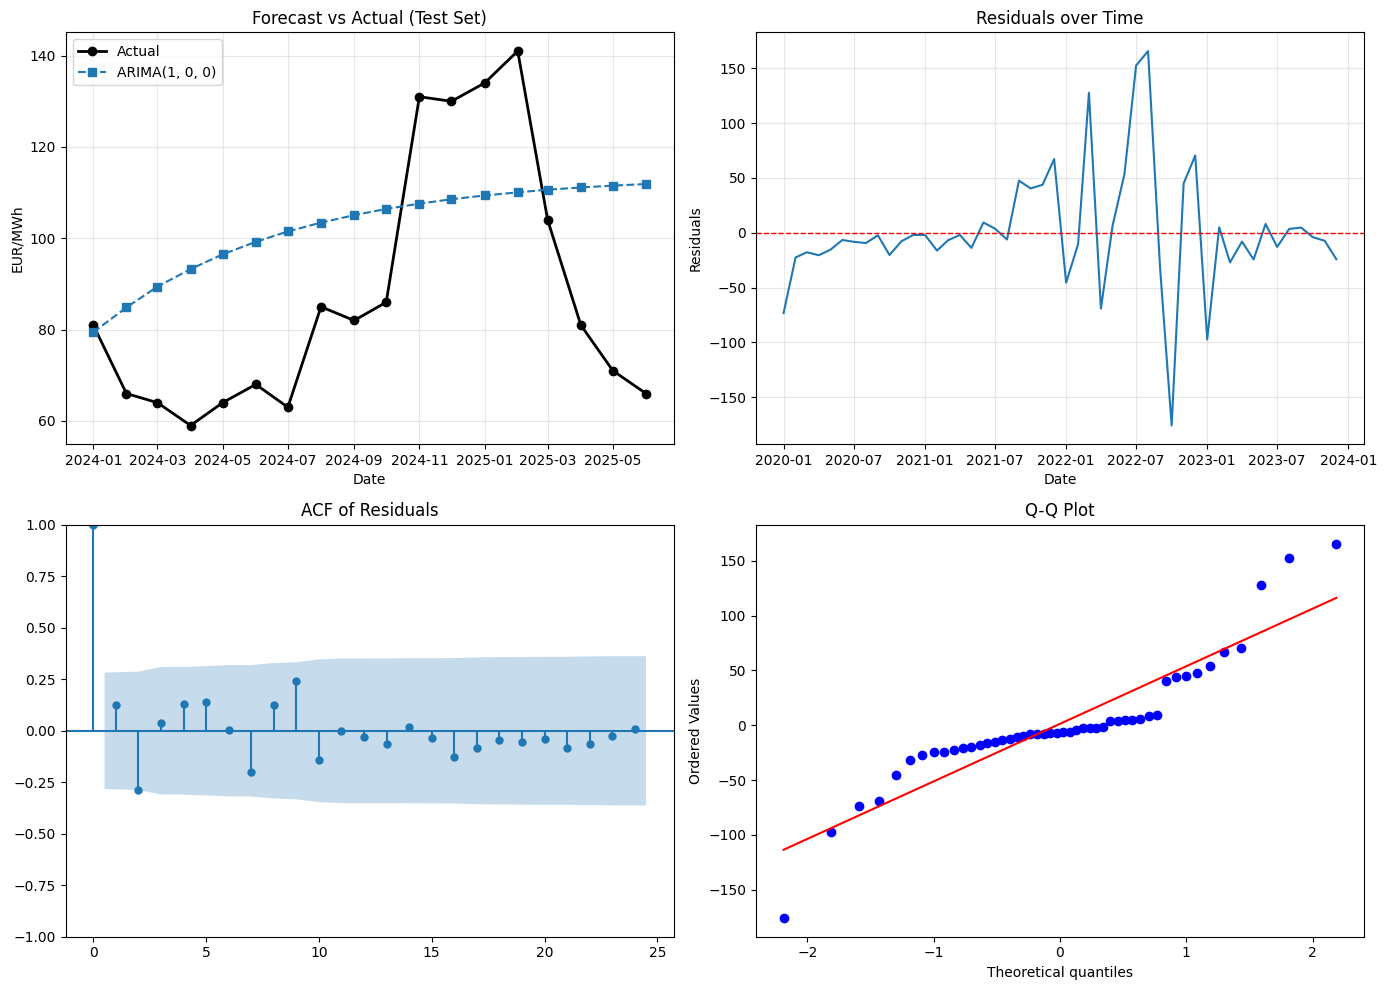

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Forecast vs Actual
axes[0, 0].plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=2, color='black')
axes[0, 0].plot(y_test.index, best_model['forecast'], 's--', label=f"ARIMA{best_model['order']}", linewidth=1.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('EUR/MWh')
axes[0, 0].set_title('Forecast vs Actual (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals over time
axes[0, 1].plot(residuals.index, residuals.values)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals over Time')
axes[0, 1].grid(True, alpha=0.3)

# 3. ACF of residuals
plot_acf(residuals, lags=24, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals')

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [ ]:
# Test ARIMA(1,0,2) - adds MA(2) term  because of significant lag 2 in (1,0,0) model
model_ma2 = ARIMA(y_train, order=(1, 0, 2))
fit_ma2 = model_ma2.fit()
forecast_ma2 = fit_ma2.forecast(steps=len(y_test))

rmse_ma2 = np.sqrt(mean_squared_error(y_test, forecast_ma2))
mae_ma2 = mean_absolute_error(y_test, forecast_ma2)
mape_ma2 = mean_absolute_percentage_error(y_test, forecast_ma2) * 100

print(f"ARIMA(1,0,2): AIC={fit_ma2.aic:.2f}, RMSE={rmse_ma2:.2f}, MAE={mae_ma2:.2f}, MAPE={mape_ma2:.1f}%")
print(fit_ma2.summary())

ARIMA(1,0,2): AIC=524.46, RMSE=26.68, MAE=24.43, MAPE=30.7%
                               SARIMAX Results                                
Dep. Variable:         price_combined   No. Observations:                   48
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -257.231
Date:                Tue, 14 Oct 2025   AIC                            524.462
Time:                        08:52:14   BIC                            533.818
Sample:                    01-01-2020   HQIC                           527.998
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        109.3277    106.261      1.029      0.304     -98.940     317.595
ar.L1          0.8960      0.119      7.556      0.000       0.664     

In [63]:
#arimax with gas prices

# Prepare exogenous variables
exog_train_gas = train[['oegpi_month']].copy()
exog_test_gas = test[['oegpi_month']].copy()

print(f"Exogenous variable: oegpi_month")
print(f"  Train: {exog_train_gas.notna().sum()[0]}/{len(exog_train_gas)} non-null")
print(f"  Test:  {exog_test_gas.notna().sum()[0]}/{len(exog_test_gas)} non-null")
print()

# Fit ARIMAX(2,1,0) + Gas
model_gas = ARIMA(y_train, exog=exog_train_gas, order=(2, 1, 0))
fit_gas = model_gas.fit()

# Forecast
forecast_gas = fit_gas.forecast(steps=len(y_test), exog=exog_test_gas)

# Metrics
rmse_gas = np.sqrt(mean_squared_error(y_test, forecast_gas))
mae_gas = mean_absolute_error(y_test, forecast_gas)
mape_gas = mean_absolute_percentage_error(y_test, forecast_gas) * 100
bias_gas = np.mean(forecast_gas - y_test)
max_error_gas = np.max(np.abs(forecast_gas - y_test))

print("ARIMAX + GAS PERFORMANCE:")
print(f"  AIC={fit_gas.aic:.2f}, BIC={fit_gas.bic:.2f}")
print(f"  RMSE={rmse_gas:.2f}, MAE={mae_gas:.2f}, MAPE={mape_gas:.1f}%")
print(f"  Bias={bias_gas:.2f}, Max Error={max_error_gas:.2f}")
print()
print("COMPARISON:")
print(f"  Univariate ARIMA: RMSE={best_model['rmse']:.2f}")
print(f"  ARIMAX + Gas:     RMSE={rmse_gas:.2f}")
print(f"  Improvement:      {((best_model['rmse']-rmse_gas)/best_model['rmse']*100):.1f}%")

Exogenous variable: oegpi_month
  Train: 48/48 non-null
  Test:  18/18 non-null

ARIMAX + GAS PERFORMANCE:
  AIC=512.29, BIC=519.69
  RMSE=30.93, MAE=23.66, MAPE=24.9%
  Bias=-8.27, Max Error=66.54

COMPARISON:
  Univariate ARIMA: RMSE=28.42
  ARIMAX + Gas:     RMSE=30.93
  Improvement:      -8.8%


In [65]:
print("\nCOEFFICIENTS:")
print(fit_gas.summary().tables[1])


COEFFICIENTS:
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
oegpi_month    -0.4787      0.338     -1.416      0.157      -1.141       0.184
ar.L1           0.2364      0.140      1.688      0.091      -0.038       0.511
ar.L2          -0.3791      0.101     -3.764      0.000      -0.576      -0.182
sigma2       2655.7966    442.181      6.006      0.000    1789.138    3522.455


In [72]:
# ============================================
# ARIMAX(1,0,2) WITH LAGGED GAS
# ============================================

# Create lagged gas variable (if not already done)
if 'oegpi_month_lag1' not in train.columns:
    train['oegpi_month_lag1'] = train['oegpi_month'].shift(1)
    test['oegpi_month_lag1'] = test['oegpi_month'].shift(1)

# Prepare exogenous
exog_train_gas_lag = train[['oegpi_month_lag1']].dropna()
exog_test_gas_lag = test[['oegpi_month_lag1']].dropna()

# Adjust y to match
y_train_gas_lag = y_train.loc[exog_train_gas_lag.index]
y_test_gas_lag = y_test.loc[exog_test_gas_lag.index]

print(f"n_train={len(y_train_gas_lag)}, n_test={len(y_test_gas_lag)}")

# Fit ARIMAX(1,0,2) with lagged gas
model_gas_lag = ARIMA(y_train_gas_lag, exog=exog_train_gas_lag, order=(1, 0, 2))
fit_gas_lag = model_gas_lag.fit()

# Forecast
forecast_gas_lag = fit_gas_lag.forecast(steps=len(y_test_gas_lag), exog=exog_test_gas_lag)

# Metrics
rmse_gas_lag = np.sqrt(mean_squared_error(y_test_gas_lag, forecast_gas_lag))
mae_gas_lag = mean_absolute_error(y_test_gas_lag, forecast_gas_lag)
mape_gas_lag = mean_absolute_percentage_error(y_test_gas_lag, forecast_gas_lag) * 100

print(f"\nCOMPARISON:")
print(f"  ARIMA(1,0,2):              RMSE={26.68:.2f}")
print(f"  ARIMAX(1,0,2) + Gas(t-1):  RMSE={rmse_gas_lag:.2f}")
print(f"\nCoefficients:")
print(fit_gas_lag.summary().tables[1])

n_train=47, n_test=17

COMPARISON:
  ARIMA(1,0,2):              RMSE=26.68
  ARIMAX(1,0,2) + Gas(t-1):  RMSE=29.40

Coefficients:
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               70.0287     39.604      1.768      0.077      -7.594     147.651
oegpi_month_lag1     0.9769      0.371      2.633      0.008       0.250       1.704
ar.L1               -0.3037      0.479     -0.634      0.526      -1.243       0.636
ma.L1                1.3175      0.426      3.093      0.002       0.483       2.152
ma.L2                0.5191      0.299      1.734      0.083      -0.068       1.106
sigma2            2709.4094    565.696      4.790      0.000    1600.665    3818.154


In [73]:
# ============================================
# GRID SEARCH: ARIMAX WITH GAS
# ============================================

models_with_gas = [
    (0, 0, 0),  # Only Gas (regression)
    (1, 0, 0),  # AR(1) + Gas
    (2, 0, 0),  # AR(2) + Gas (previous test)
    (0, 0, 1),  # MA(1) + Gas
    (0, 0, 2),  # MA(2) + Gas
    (1, 0, 1),  # ARMA(1,1) + Gas
    (1, 0, 2),  # ARMA(1,2) + Gas (current)
    (2, 0, 1),  # ARMA(2,1) + Gas
]

results_gas = []

for order in models_with_gas:
    try:
        model = ARIMA(y_train_gas_lag, exog=exog_train_gas_lag, order=order)
        fit = model.fit()
        forecast = fit.forecast(steps=len(y_test_gas_lag), exog=exog_test_gas_lag)
        
        rmse = np.sqrt(mean_squared_error(y_test_gas_lag, forecast))
        mae = mean_absolute_error(y_test_gas_lag, forecast)
        mape = mean_absolute_percentage_error(y_test_gas_lag, forecast) * 100
        
        # Check if Gas is significant
        gas_pval = fit.pvalues['oegpi_month_lag1']
        
        results_gas.append({
            'order': order,
            'aic': fit.aic,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'gas_pval': gas_pval,
            'model': fit,
            'forecast': forecast
        })
        
        print(f"ARIMAX{order} + Gas: AIC={fit.aic:.2f}, RMSE={rmse:.2f}, Gas p={gas_pval:.3f}")
        
    except Exception as e:
        print(f"ARIMAX{order}: Failed - {e}")

# Best by RMSE
best_gas = min(results_gas, key=lambda x: x['rmse'])
print(f"\nBest ARIMAX: {best_gas['order']}, RMSE={best_gas['rmse']:.2f}, Gas p={best_gas['gas_pval']:.3f}")

ARIMAX(0, 0, 0) + Gas: AIC=542.12, RMSE=27.19, Gas p=0.000
ARIMAX(1, 0, 0) + Gas: AIC=517.54, RMSE=28.04, Gas p=0.112
ARIMAX(2, 0, 0) + Gas: AIC=523.40, RMSE=27.92, Gas p=0.001
ARIMAX(0, 0, 1) + Gas: AIC=516.38, RMSE=28.01, Gas p=0.000
ARIMAX(0, 0, 2) + Gas: AIC=516.31, RMSE=29.53, Gas p=0.001
ARIMAX(1, 0, 1) + Gas: AIC=516.55, RMSE=30.07, Gas p=0.034
ARIMAX(1, 0, 2) + Gas: AIC=518.14, RMSE=29.40, Gas p=0.008
ARIMAX(2, 0, 1) + Gas: AIC=518.53, RMSE=29.48, Gas p=0.024

Best ARIMAX: (0, 0, 0), RMSE=27.19, Gas p=0.000


In [74]:
# ============================================
# ARIMAX WITH CO2 - FULL TRAINING PERIOD
# ============================================

# Full training period (CO2 available from 2015)
train_full = df[(df.index >= '2015-01') & (df.index <= split_date)].copy()
test_co2 = df[(df.index > split_date) & (df.index <= '2025-06')].copy()

# Target
y_train_full = train_full['price_combined']
y_test_co2 = test_co2['price_combined']

# Create CO2 lag-1
train_full['co2_lag1'] = train_full['carbonprices_primary_market'].shift(1)
test_co2['co2_lag1'] = test_co2['carbonprices_primary_market'].shift(1)

# Prepare exogenous
exog_train_co2 = train_full[['co2_lag1']].dropna()
exog_test_co2 = test_co2[['co2_lag1']].dropna()

y_train_co2 = y_train_full.loc[exog_train_co2.index]
y_test_co2_adj = y_test_co2.loc[exog_test_co2.index]

print(f"CO2: n_train={len(y_train_co2)}, n_test={len(y_test_co2_adj)}")

# Grid search
models_co2 = [
    (0, 0, 0),  # Pure regression
    (1, 0, 0),  # AR(1) + CO2
    (2, 0, 0),  # AR(2) + CO2
    (1, 0, 1),  # ARMA(1,1) + CO2
    (1, 0, 2),  # ARMA(1,2) + CO2
    (2, 0, 1),  # ARMA(2,1) + CO2
]

results_co2 = []

for order in models_co2:
    try:
        model = ARIMA(y_train_co2, exog=exog_train_co2, order=order)
        fit = model.fit()
        forecast = fit.forecast(steps=len(y_test_co2_adj), exog=exog_test_co2)
        
        rmse = np.sqrt(mean_squared_error(y_test_co2_adj, forecast))
        mae = mean_absolute_error(y_test_co2_adj, forecast)
        co2_pval = fit.pvalues['co2_lag1']
        
        results_co2.append({
            'order': order,
            'aic': fit.aic,
            'rmse': rmse,
            'mae': mae,
            'co2_pval': co2_pval,
            'model': fit,
            'forecast': forecast
        })
        
        print(f"ARIMAX{order} + CO2: AIC={fit.aic:.2f}, RMSE={rmse:.2f}, CO2 p={co2_pval:.3f}")
        
    except Exception as e:
        print(f"ARIMAX{order}: Failed - {e}")

best_co2 = min(results_co2, key=lambda x: x['rmse'])
print(f"\nBest ARIMAX + CO2: {best_co2['order']}, RMSE={best_co2['rmse']:.2f}, CO2 p={best_co2['co2_pval']:.3f}")
print(f"\nBaseline: ARIMA(1,0,2) RMSE=26.68")

CO2: n_train=107, n_test=17
ARIMAX(0, 0, 0) + CO2: AIC=1170.00, RMSE=63.11, CO2 p=0.000
ARIMAX(1, 0, 0) + CO2: AIC=1073.40, RMSE=44.28, CO2 p=0.000
ARIMAX(2, 0, 0) + CO2: AIC=1072.28, RMSE=50.15, CO2 p=0.000
ARIMAX(1, 0, 1) + CO2: AIC=1067.14, RMSE=50.12, CO2 p=0.000
ARIMAX(1, 0, 2) + CO2: AIC=1065.33, RMSE=36.86, CO2 p=0.000
ARIMAX(2, 0, 1) + CO2: AIC=1067.35, RMSE=45.20, CO2 p=0.000

Best ARIMAX + CO2: (1, 0, 2), RMSE=36.86, CO2 p=0.000

Baseline: ARIMA(1,0,2) RMSE=26.68
